In [1]:
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib import style 


In [2]:
style.use('ggplot')
data = yf.Ticker('AAPL').history('1y')
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-03-24 00:00:00-04:00,220.040973,220.518886,217.631476,219.772141,44299500,0.0,0.0
2025-03-25 00:00:00-04:00,219.811973,223.127525,219.124965,222.779037,34493600,0.0,0.0
2025-03-26 00:00:00-04:00,222.540068,224.043525,219.513267,220.568665,34466100,0.0,0.0
2025-03-27 00:00:00-04:00,220.429300,224.013684,219.602900,222.878632,37094800,0.0,0.0
2025-03-28 00:00:00-04:00,220.708051,222.838764,216.735360,216.954407,39818600,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-17 00:00:00-04:00,252.960007,255.130005,252.179993,254.229996,32361600,0.0,0.0
2026-03-18 00:00:00-04:00,252.630005,254.940002,249.000000,249.940002,35757900,0.0,0.0
2026-03-19 00:00:00-04:00,249.399994,251.830002,247.300003,248.960007,34864100,0.0,0.0


<Axes: xlabel='Date'>

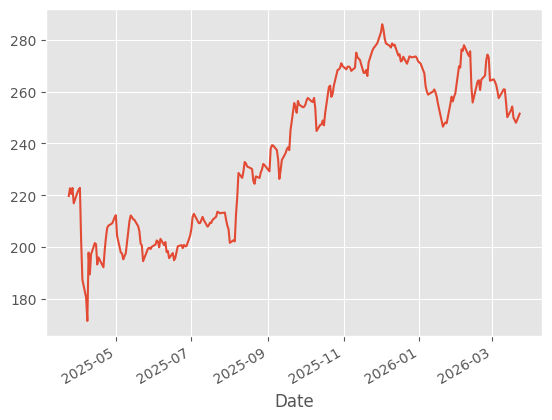

In [3]:
data['Close'].plot()

In [4]:
data['100ma'] = data['Close'].rolling(window=100, min_periods=0).mean()
data.dropna()
data.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,100ma
Date,,,,,,,,
2026-03-17 00:00:00-04:00,252.960007,255.130005,252.179993,254.229996,32361600,0.0,0.0,267.189480
2026-03-18 00:00:00-04:00,252.630005,254.940002,249.000000,249.940002,35757900,0.0,0.0,267.109296
2026-03-19 00:00:00-04:00,249.399994,251.830002,247.300003,248.960007,34864100,0.0,0.0,267.008035
2026-03-20 00:00:00-04:00,247.979996,249.199997,246.000000,247.990005,88331100,0.0,0.0,266.864734
2026-03-23 00:00:00-04:00,253.990005,254.559998,250.279999,251.490005,37465587,0.0,0.0,266.696648


<BarContainer object of 251 artists>

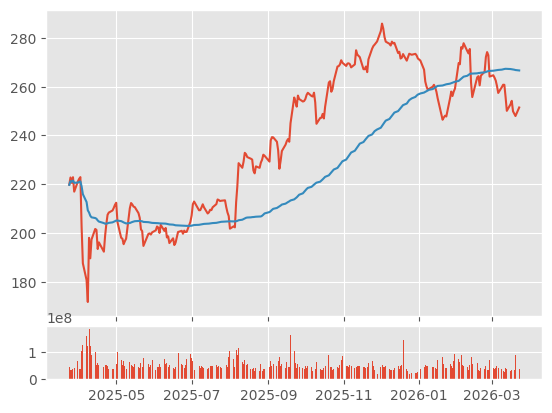

In [5]:
ax1 = plt.subplot2grid((6,1), (0,0), rowspan=5, colspan=5)
ax2 = plt.subplot2grid((6,1), (5,0), rowspan=1, colspan=1, sharex=ax1)

ax1.plot(data.index, data['Close'])
ax1.plot(data.index, data['100ma'])
ax2.bar(data.index, data['Volume'])

In [6]:
import mplfinance as mpf

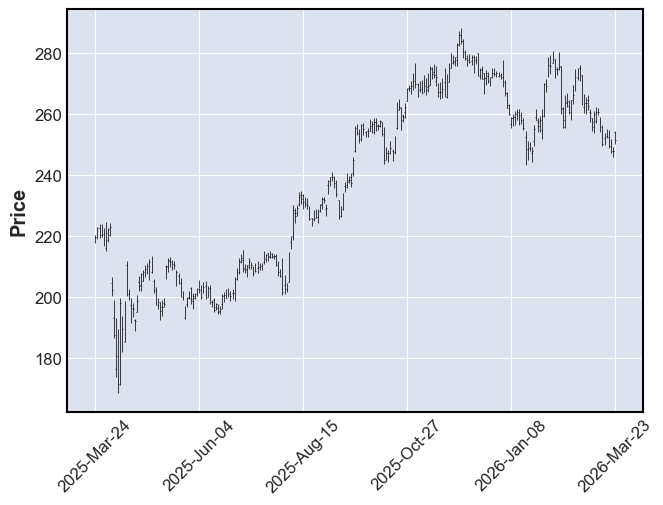

In [7]:
mpf.plot(data)

In [8]:
data_ohlc = data['Close'].resample('10D').ohlc()
data_volume = data['Volume'].resample('10D').sum()
data_ohlc.head()

,open,high,low,close
Date,,,,
2025-03-24 00:00:00-04:00,219.772141,222.918427,216.954407,222.918427
2025-04-03 00:00:00-04:00,202.308258,202.308258,171.671783,197.290131
2025-04-13 00:00:00-04:00,201.641174,201.641174,192.321777,198.873245
2025-04-23 00:00:00-04:00,203.712128,212.394302,203.712128,204.458908
2025-05-03 00:00:00-04:00,198.026901,210.150482,195.398361,210.150482


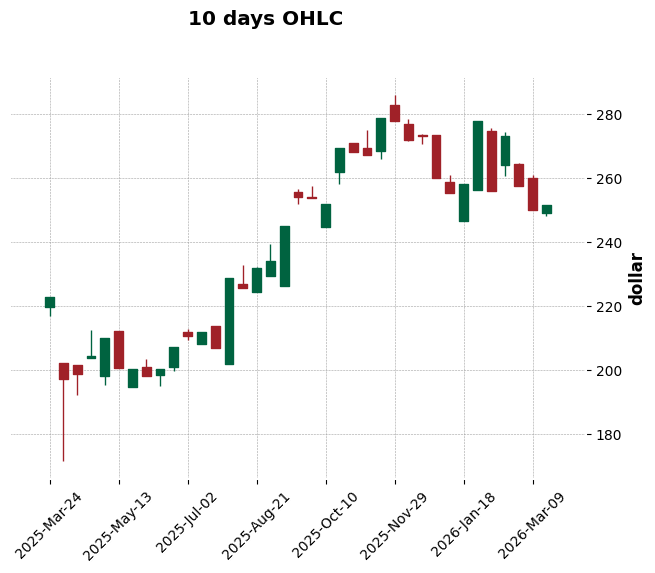

In [9]:
mpf.plot(data_ohlc,type='candle', style='charles',
        title='10 days OHLC',
        ylabel = 'dollar')

In [10]:
import pickle 
import requests
import bs4 as bs

In [11]:
def save_sp500_tickers():
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    resp = requests.get(
        'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
        headers=headers
    )
    df = pd.read_html(resp.text)[0]
    tickers = df['Symbol'].tolist()
    tickers = [t.replace('.', '-') for t in tickers]
    
    with open('sp500tickers.pickle', 'wb') as f:
        pickle.dump(tickers, f)
    
    print(f'{len(tickers)} tickers found')
    return tickers

save_sp500_tickers()

503 tickers found


/var/folders/h4/mgpvszm15k53ykxyhygbfb7w0000gn/T/ipykernel_22745/2752029350.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(resp.text)[0]


['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'CAG',
 'CO

In [12]:
import os 

In [17]:
def get_data_from_yahoo(reload_sp500=False): 
    if reload_sp500:
        tickers = save_sp500_tickers()
    else:
        with open('sp500tickers.pickle', 'rb') as f:
            tickers = pickle.load(f)
    
    if not os.path.exists('stock_dfs'):
        os.makedirs('stock_dfs')
    
    for ticker in tickers:
        print(ticker)
        if not os.path.exists('stock_dfs/{}.csv'.format(ticker)):
            df = yf.download(ticker, start='2000-01-01', end='2024-01-01')
            df.to_csv('stock_dfs/{}.csv'.format(ticker))
        else:
            print('Already have {}'.format(ticker))

get_data_from_yahoo()

MMM


[*********************100%***********************]  1 of 1 completed


AOS


[*********************100%***********************]  1 of 1 completed


ABT


...

[*********************100%***********************]  1 of 1 completed


ZBH


[*********************100%***********************]  1 of 1 completed


ZTS


[*********************100%***********************]  1 of 1 completed


In [21]:
def compile_data():
    with open('sp500tickers.pickle', 'rb') as f:
        tickers = pickle.load(f)
    
    main_df = pd.DataFrame()
    
    for count, ticker in enumerate(tickers):
        try:
            df = pd.read_csv('stock_dfs/{}.csv'.format(ticker), index_col=0)
            df.rename(columns={'Close': ticker}, inplace=True)
            df.drop(['Open', 'High', 'Low', 'Volume'], axis=1, inplace=True)
            
            if main_df.empty:
                main_df = df
            else:
                main_df = main_df.join(df, how='outer')
            
            if count % 10 == 0:
                print(count)
                
        except Exception as e:
            print(f'Error with {ticker}: {e}')
    
    print(main_df.head())
    main_df.to_csv('sp500_joined_closes.csv')

compile_data()

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
Error with Q: columns overlap but no suffix specified: Index(['Adj Close'], dtype='object')
390
400
Error with SNDK: columns overlap but no suffix specified: Index(['Adj Close'], dtype='object')
410
Error with SOLV: columns overlap but no suffix specified: Index(['Adj Close'], dtype='object')
420
430
440
450
460
470
480
490
500
                           MMM                 AOS                ABT ABBV  \
Price                                                                        
2000-01-03  19.257408142089844  2.2540676593780518  8.093061447143555  NaN   
2000-01-04   18.49220085144043   2.221588134765625  7.861825466156006  NaN   
2000-01-05   19.02783966064453  2.2150919437408447  7.847376346588135  NaN   
2000-01-06    20.5582332611084  2.1826131343841553   8.12196159362793  NaN   
2000-01-07  20.966337203979492   2.273554801940918  8.208